<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Week_6_10_5_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 6 - 10.5 Clustering
###STATS 302 Principle of Machine Learning
###Duke Kunshan University

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc

import matplotlib.pyplot as plt

## 10.5.1 K-Means Clustering

In [2]:
# set seed
np.random.seed(2)
X = np.random.normal(size = (50,2))
X[:25,0] += 3
X[:25,1] -= 4

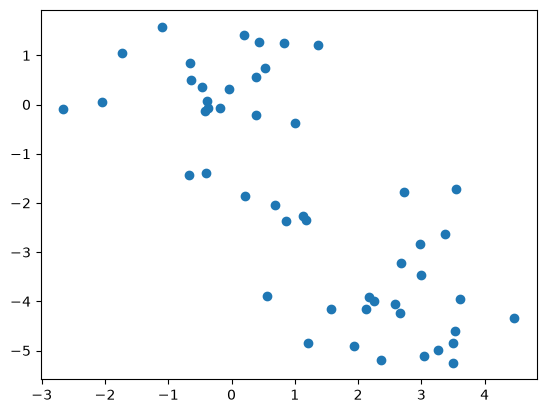

In [3]:
plt.scatter(X[:,0],X[:,1])

In [4]:
clustering = KMeans(n_clusters = 2,n_init=20)  # Run the entire K-Means algorithm 20 separate times, each starting with different initial centroids.
clustering.fit(X)  # Unsuperivsed learning, still fit on the same entire data set!

D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 2)","[[-

In [5]:
clusters = clustering.predict(X)

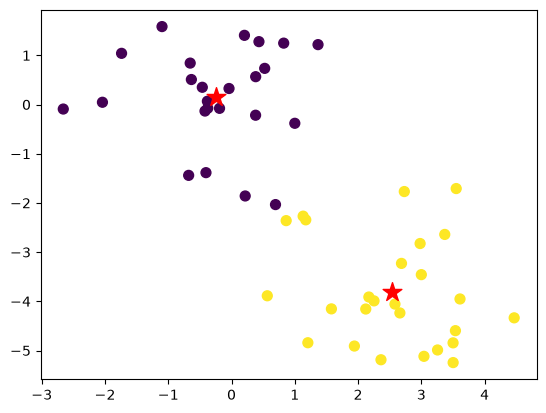

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50)

centers = clustering.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],marker = '*', c='red', s=200, alpha=1)

In [7]:
np.bincount(clusters)
# 24 obs are classified in cluster 1, and 26 in cluster 2/

array([24, 26])

### Using different values of n_init for k  = 3
##### n_init: int, default=10
##### Number of time the k-means algorithm will be run with different centroid seeds.

D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0.5, 1.0, 'N_init = 20')

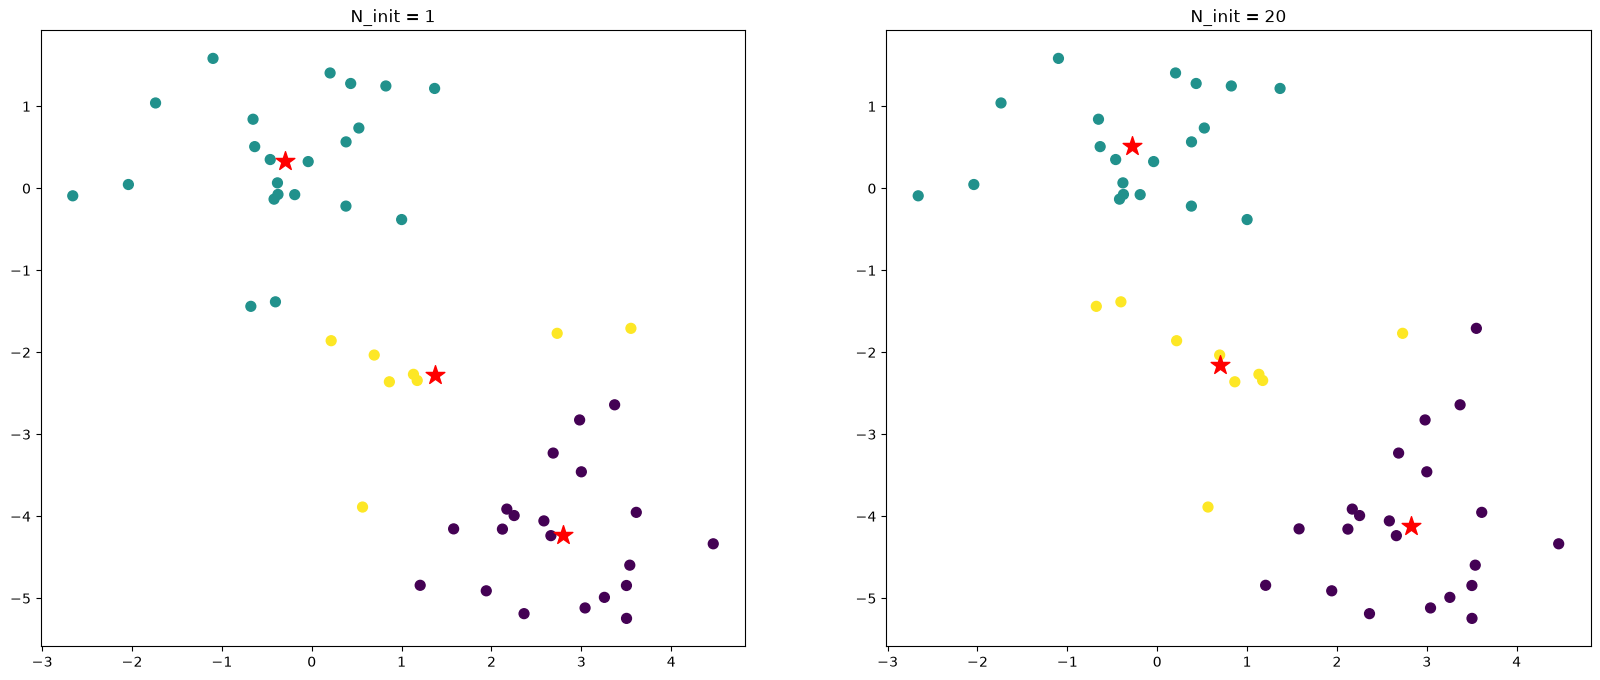

In [8]:
fig,ax = plt.subplots(1,2,figsize = (20,8))

# n_init = 1
clustering = KMeans(n_clusters = 3,n_init=1)
clustering.fit(X)

clusters = clustering.predict(X)

ax[0].scatter(X[:, 0], X[:, 1], c=clusters, s=50)

centers = clustering.cluster_centers_
ax[0].scatter(centers[:, 0], centers[:, 1],marker = '*', c='red', s=200, alpha=1)
ax[0].set_title('N_init = 1')

# n_init = 20
clustering = KMeans(n_clusters = 3,n_init=20)
clustering.fit(X)

clusters = clustering.predict(X)

ax[1].scatter(X[:, 0], X[:, 1], c=clusters, s=50)

centers = clustering.cluster_centers_
ax[1].scatter(centers[:, 0], centers[:, 1],marker = '*', c='red', s=200, alpha=1)
ax[1].set_title('N_init = 20')

It is suggested that we should not go for a very small value of n_init

## 10.5.2  Hierarchical Clustering

In [10]:
# before applying hierachical clutering lets scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Mean of first feature before scaling - ',X[:,0].mean())
print('Mean of first feature after scaling - ',X_scaled[:,0].mean())
# after scaling, its pretty close to 0

print('Mean of second feature before scaling - ',X[:,1].mean())
print('Mean of second feature after scaling - ',X_scaled[:,1].mean())

Mean of first feature before scaling -  1.2021804941282386
Mean of first feature after scaling -  2.3293866835416566e-16
Mean of second feature before scaling -  -1.909662761893434
Mean of second feature after scaling -  1.7486012637846215e-16


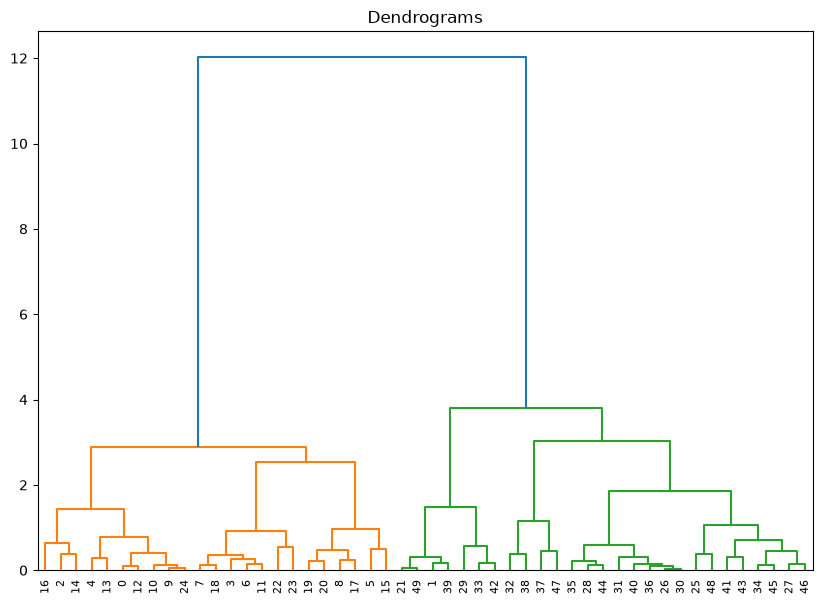

In [11]:
# dendrogram: hierarchical clustering does not require you to specify the number of clusters beforehand
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X_scaled, method='ward'))  # Ward's method chooses the merge that causes the smallest increase in the total within-cluster variance

### Using heirachical clustering for clustering points in 2 groups

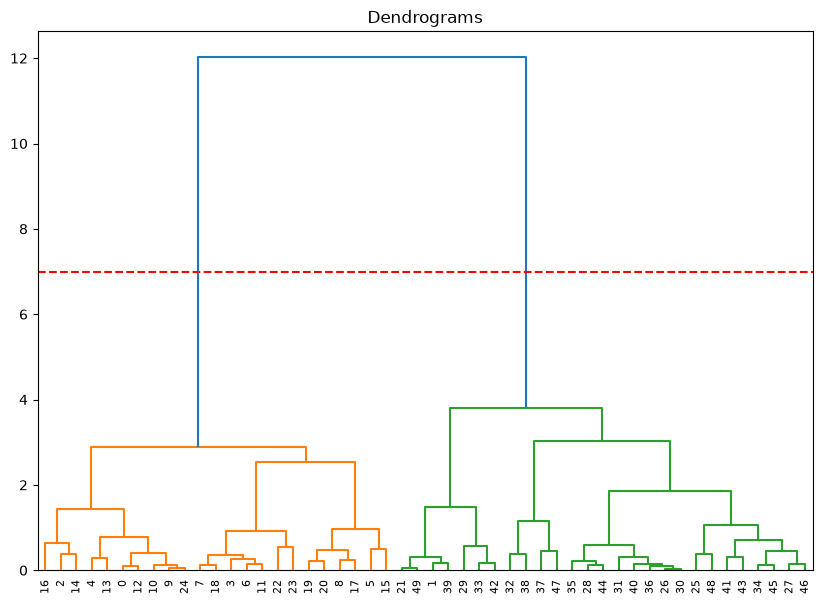

In [12]:
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X_scaled, method='ward'))
plt.axhline(y = 7,c = 'red',linestyle = '--')

In [13]:
#getting predictions
cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
cluster.fit_predict(X_scaled)

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

array([1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 2])

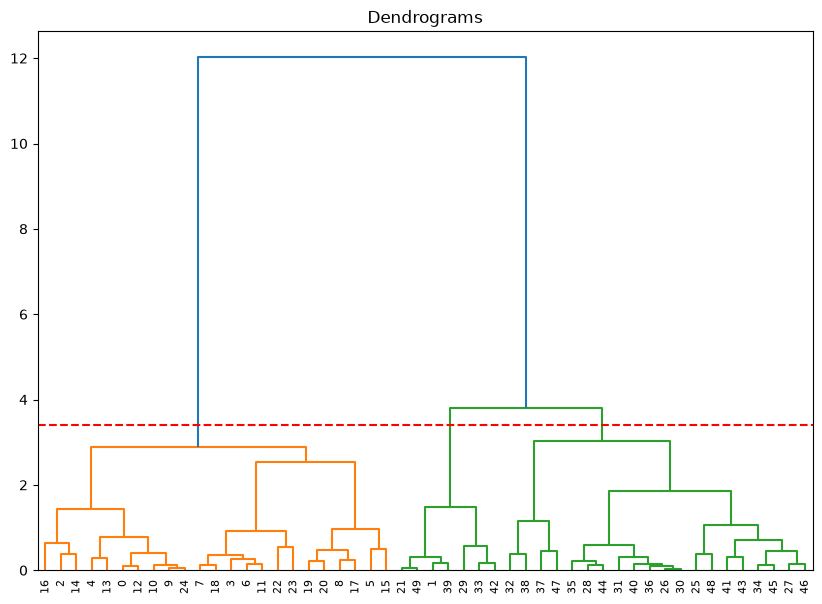

In [14]:
# 3 CLUTERSabs
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X_scaled, method='ward'))
plt.axhline(y = 3.4,c = 'red',linestyle = '--')

#getting predictions
cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
# affinity here is the method used for calucating distance, and through linkage we can speify the different types
# of linkages
cluster.fit_predict(X_scaled)